# Nettoyage des données

## Import des bibliothèques

In [1]:
import pandas as pd
import os
import glob
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

## Import du dataset

In [2]:
repertoire_data_processed = Path.cwd().parent.parent / "data" / "processed"

try:
    path_dataset = next(repertoire_data_processed.glob("01_dataset_bronze.csv"))
    print(f"Fichier trouvé : {path_dataset}")
    
    # Lecture
    df = pd.read_csv(path_dataset)
except StopIteration:
    print("Erreur : Le fichier '01_dataset_bronze.csv' est introuvable dans le dossier.")

Fichier trouvé : /home/julien/Repos/fil_rouge-etude_chomage_france/data/processed/01_dataset_bronze.csv


In [3]:
df.head(20)

,date,annee,trimestre,mois,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,...,isj,ipc_energie_only,indicateur_confiance_menage,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel,pib,ict,nb_defaillances_entreprise,nb_interimaires
0,1990-01-01,1990,1,1,8.1,6.3,10.3,16.9,6.9,5.1,...,NaN,NaN,114.561378,115.7,NaN,1.0,388956.0,NaN,3998.0,NaN
1,1990-02-01,1990,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,112.722007,113.5,NaN,0.9,NaN,NaN,3815.0,NaN
2,1990-03-01,1990,1,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,113.375632,111.5,NaN,0.9,NaN,NaN,4304.0,NaN
3,1990-04-01,1990,2,4,8.0,6.3,10.2,16.8,6.8,5.1,...,NaN,NaN,111.500642,110.9,NaN,0.7,391046.0,NaN,3506.0,NaN
4,1990-05-01,1990,2,5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,109.385755,110.7,NaN,0.9,NaN,NaN,3744.0,NaN
5,1990-06-01,1990,2,6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,112.137687,108.9,NaN,1.0,NaN,NaN,4060.0,NaN
6,1990-07-01,1990,3,7,8.0,6.3,10.1,16.7,6.8,5.1,...,NaN,NaN,112.337601,109.9,NaN,1.0,393587.0,NaN,3803.0,NaN
7,1990-08-01,1990,3,8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,107.870528,103.9,NaN,-0.9,NaN,NaN,1679.0,NaN
8,1990-09-01,1990,3,9,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,103.139645,102.8,NaN,-1.0,NaN,NaN,3934.0,NaN
9,1990-10-01,1990,4,10,8.0,6.3,10.0,16.9,6.8,5.1,...,NaN,NaN,104.922785,101.9,NaN,-1.0,393398.0,NaN,4808.0,NaN


In [4]:
df.tail(20)

,date,annee,trimestre,mois,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,...,isj,ipc_energie_only,indicateur_confiance_menage,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel,pib,ict,nb_defaillances_entreprise,nb_interimaires
417,2024-08-01,2024,3,8,NaN,NaN,NaN,NaN,NaN,NaN,...,1.7,0.4,92.153374,96.6,98.4,0.7,NaN,NaN,1599.0,NaN
418,2024-09-01,2024,3,9,NaN,NaN,NaN,NaN,NaN,NaN,...,1.4,-3.3,95.207348,97.4,98.6,-0.8,NaN,NaN,6314.0,NaN
419,2024-10-01,2024,4,10,7.3,7.4,7.1,18.7,6.6,4.7,...,1.4,-2.0,93.585940,97.0,97.4,-0.9,654734.0,111.3,6554.0,713974.330136
420,2024-11-01,2024,4,11,NaN,NaN,NaN,NaN,NaN,NaN,...,1.5,-0.7,90.206746,96.1,98.4,-0.7,NaN,NaN,6099.0,NaN
421,2024-12-01,2024,4,12,NaN,NaN,NaN,NaN,NaN,NaN,...,1.3,1.2,88.566046,95.0,96.5,-0.9,NaN,NaN,5752.0,NaN
422,2025-01-01,2025,1,1,7.5,7.5,7.4,19.2,6.8,4.8,...,1.4,2.7,91.806695,95.4,97.0,-0.7,655389.0,112.3,5948.0,710419.927973
423,2025-02-01,2025,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,1.3,-5.8,92.647747,95.9,93.5,-0.6,NaN,NaN,5826.0,NaN
424,2025-03-01,2025,1,3,NaN,NaN,NaN,NaN,NaN,NaN,...,1.3,-6.6,90.964128,96.6,96.4,-0.6,NaN,NaN,6382.0,NaN
425,2025-04-01,2025,2,4,7.6,7.7,7.4,19.1,6.9,4.8,...,1.3,-7.8,91.175240,97.1,97.8,-0.3,657523.0,112.2,5863.0,709895.580836
426,2025-05-01,2025,2,5,NaN,NaN,NaN,NaN,NaN,NaN,...,1.1,-8.0,88.309880,95.5,93.6,-0.1,NaN,NaN,5475.0,NaN


## Colonnes présentes

In [5]:
df.columns

Index(['date', 'annee', 'trimestre', 'mois', 'taux_chomage_total_insee',
       'taux_chomage_homme_insee', 'taux_chomage_femme_insee',
       'taux_chomage_15_24_insee', 'taux_chomage_25_49_insee',
       'taux_chomage_50_plus_insee', 'demandeur_total_abcd_total',
       'demandeur_homme_abcd_total', 'demandeur_femme_abcd_total',
       'demandeur_total_abcd_moins25', 'demandeur_total_abcd_2549',
       'demandeur_total_abcd_plus50', 'demandeur_homme_abcd_moins25',
       'demandeur_homme_abcd_2549', 'demandeur_homme_abcd_plus50',
       'demandeur_femme_abcd_moins25', 'demandeur_femme_abcd_2549',
       'demandeur_femme_abcd_plus50', 'nb_offres_france_travail',
       'population_active', 'taux_chomage_ocde', 'taux_euribor_3m', 'mro',
       'taux_change_eur_dollar', 'ipc', 'isj', 'ipc_energie_only',
       'indicateur_confiance_menage', 'indicateur_climat_affaires',
       'indicateur_climat_emploi', 'indicateur_retournement_conjoncturel',
       'pib', 'ict', 'nb_defaillances_entre

## Type de données

In [6]:
df.dtypes

date                                        str
annee                                     int64
trimestre                                 int64
mois                                      int64
taux_chomage_total_insee                float64
taux_chomage_homme_insee                float64
taux_chomage_femme_insee                float64
taux_chomage_15_24_insee                float64
taux_chomage_25_49_insee                float64
taux_chomage_50_plus_insee              float64
demandeur_total_abcd_total              float64
demandeur_homme_abcd_total              float64
demandeur_femme_abcd_total              float64
demandeur_total_abcd_moins25            float64
demandeur_total_abcd_2549               float64
demandeur_total_abcd_plus50             float64
demandeur_homme_abcd_moins25            float64
demandeur_homme_abcd_2549               float64
demandeur_homme_abcd_plus50             float64
demandeur_femme_abcd_moins25            float64
demandeur_femme_abcd_2549               

Commentaires : 
- "date" est défini comme un STRING. On peut le transformer en un TIMESTAMP
- "taux_change_eur_dollar" est défini comme un STRING. On peut le transformer en un FLOAT


### Conversion de la colonne date au format datetime

In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
df['taux_change_eur_dollar'] = df['taux_change_eur_dollar'].str.replace(',', '.').astype(float)

In [9]:
df[['date','taux_change_eur_dollar']].tail(10)

,date,taux_change_eur_dollar
427,2025-06-01,1.1720
428,2025-07-01,1.1446
429,2025-08-01,1.1658
430,2025-09-01,1.1741
431,2025-10-01,1.1554
432,2025-11-01,1.1566
433,2025-12-01,1.1750
434,2026-01-01,1.1919
435,2026-02-01,1.1805
436,2026-03-01,NaN


In [10]:
df[['date','taux_change_eur_dollar']].dtypes

date                      datetime64[us]
taux_change_eur_dollar           float64
dtype: object

### Description du dataset

In [11]:
df.describe()

,date,annee,trimestre,mois,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,...,isj,ipc_energie_only,indicateur_confiance_menage,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel,pib,ict,nb_defaillances_entreprise,nb_interimaires
count,437,437.000000,437.000000,437.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,...,421.000000,422.000000,436.000000,434.000000,422.000000,434.000000,145.000000,113.000000,432.000000,103.000000
mean,2008-01-15 22:27:44.073226,2007.588101,2.482838,6.443936,8.975342,8.468493,9.573973,21.575342,8.093836,5.752055,...,1.478860,3.230095,99.029010,100.092857,100.009479,0.182811,529179.234483,85.636283,4471.835648,661273.427517
min,1990-01-01 00:00:00,1990.000000,1.000000,1.000000,7.100000,6.300000,6.800000,16.500000,6.300000,4.100000,...,-0.100000,-18.300000,79.867693,45.700000,42.000000,-1.000000,388956.000000,60.300000,703.000000,477838.210451
25%,1999-01-01 00:00:00,1999.000000,1.000000,3.000000,8.000000,7.600000,8.700000,19.025000,7.200000,5.100000,...,0.700000,-1.500000,90.989131,94.625000,94.000000,-0.700000,459345.000000,74.100000,3964.250000,593762.607550
50%,2008-01-01 00:00:00,2008.000000,2.000000,6.000000,9.000000,8.400000,9.600000,21.850000,8.100000,5.750000,...,1.200000,2.050000,99.158716,101.250000,100.950000,0.700000,546199.000000,88.200000,4684.500000,640411.444797
75%,2017-02-01 00:00:00,2017.000000,3.000000,9.000000,10.075000,9.275000,10.300000,23.800000,9.100000,6.400000,...,1.700000,7.875000,104.849888,107.100000,107.200000,0.900000,590306.000000,96.400000,5369.750000,730857.542042
max,2026-03-01 00:00:00,2026.000000,4.000000,12.000000,10.700000,11.000000,12.100000,27.900000,9.800000,7.200000,...,6.100000,33.100000,126.235294,121.000000,120.000000,1.000000,661062.000000,112.800000,6897.000000,821378.102512
std,NaN,10.469249,1.124295,3.476618,1.082370,1.169129,1.409429,2.983438,1.031117,0.741408,...,1.127093,7.499034,10.021342,9.920619,9.977588,0.819373,81043.124941,14.409341,1240.152331,89845.599252


Commentaire : ATTENTION aux variables d'indices !!!

- indicateur_retournement_conjoncturel
- ipc_energie_only
- ipc
- isj
- indicateur_confiance_menage

à recalculer en premier lieu !

# Valeurs manquantes

## La problématique

Nous avons de nombreuses sources de données, chacune présentant des périodes et des fréquences de mises à jour différentes.

| Titre (Variable) | Fréquence | Date début | Date fin |
| :--- | :--- | :--- | :--- |
| Taux de chômage total INSEE (`taux_chomage_total_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage Homme INSEE (`taux_chomage_homme_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage Femme INSEE (`taux_chomage_femme_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage 15-24 ans INSEE (`taux_chomage_15_24_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage 25-49 ans INSEE (`taux_chomage_25_49_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage 50 ans et plus INSEE (`taux_chomage_50_plus_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| DEFM Total ABCDE (`demandeur_total_abcd_total`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes ABCDE (`demandeur_homme_abcd_total`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes ABCDE (`demandeur_femme_abcd_total`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM -25 ans ABCDE (`demandeur_total_abcd_moins25`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM 25-49 ans ABCDE (`demandeur_total_abcd_2549`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM 50 ans et plus ABCDE (`demandeur_total_abcd_plus50`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes -25 ans ABCDE (`demandeur_homme_abcd_moins25`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes 25-49 ans ABCDE (`demandeur_homme_abcd_2549`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes 50 ans+ ABCDE (`demandeur_homme_abcd_plus50`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes -25 ans ABCDE (`demandeur_femme_abcd_moins25`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes 25-49 ans ABCDE (`demandeur_femme_abcd_2549`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes 50 ans+ ABCDE (`demandeur_femme_abcd_plus50`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| Taux de chômage (OCDE) (`taux_chomage_ocde`) | Mensuelle | 01/01/1990 | 31/10/2025 |
| Offres d'emploi collectées par France Travail (`nb_offres_france_travail`) | Mensuelle | 01/01/1996 | 31/01/2026 |
| Population active (OIT) (`population_active`) | Annuelle | 01/01/1990 | 31/12/2024 |
| Euribor 3-month (`taux_euribor_3m`) | Mensuelle | 31/01/1994 | 31/12/2025 |
| Main refinancing operations (`MRO`) | Ponctuelle | 01/01/1999 | 11/06/2025 |
| Taux de change EURO <> DOLLAR (`taux_change_eur_dollar`) | Mensuelle | 01/01/1990 | 28/02/2026 |
| Indice des prix à la consommation (`ipc`) | Mensuelle | 01/01/1991 | 31/12/2025 |
| IPC énergie (`ipc_energie_only`) | Mensuelle | 01/01/1991 | 31/12/2025 |
| Inflation sous-jacente (`isj`) | Mensuelle | 01/01/1991 | 30/11/2025 |
| Indicateur de confiance des ménages (`indicateur_confiance_menage`) | Mensuelle | 01/01/1972 | 28/02/2025 |
| Climat des affaires (`indicateur_climat_affaires`) | Mensuelle | 01/01/1977 | 31/12/2025 |
| Climat de l'emploi (`indicateur_climat_emploi`) | Mensuelle | 01/01/1991 | 31/12/2025 |
| Retournement conjoncturel (`indicateur_retournement_conjoncturel`) | Mensuelle | 01/01/1988 | 31/12/2025 |
| PIB - Produit intérieur brut total (`pib`) | Trimestrielle | 01/01/1949 | 30/09/2025 |
| Indice du coût du travail (`ict`) | Trimestrielle | 01/01/1988 | 30/09/2025 |
| Défaillances d'entreprises (`nb_defaillances_entreprise`) | Mensuelle | 31/01/1990 | 31/10/2025 |
| L'emploi intérimaire (`nb_interimaires`) | Trimestrielle | 01/01/2000 | 30/09/2025 |

Le dataset présente une granularité maximale au mois cependant de nombreuses variables sont trimestrialisées.

Pour régler ce problème, nous pourrions rester au trimestre pour les raisons suivantes :

1) Fiabilité : En restant au trimestre, nous travaillons sur des données réelles (non interpolées) ==> pas d'information "artificielle".
2) Stabilité : Les variations mensuelles du chômage ou de l'inflation peuvent être "bruitées" par des facteurs saisonniers très courts. Le trimestre lisse ce bruit
3) Cohérence : La majorité des colonnes centrales (chômage par âge/sexe, demandeurs d'emploi, PIB, ICT) sont déjà à cette fréquence, de même que notre target "taux_chomage_total_insee" 

## Apercu des valeurs manquantes

In [12]:
df.isna().any()

date                                    False
annee                                   False
trimestre                               False
mois                                    False
taux_chomage_total_insee                 True
taux_chomage_homme_insee                 True
taux_chomage_femme_insee                 True
taux_chomage_15_24_insee                 True
taux_chomage_25_49_insee                 True
taux_chomage_50_plus_insee               True
demandeur_total_abcd_total               True
demandeur_homme_abcd_total               True
demandeur_femme_abcd_total               True
demandeur_total_abcd_moins25             True
demandeur_total_abcd_2549                True
demandeur_total_abcd_plus50              True
demandeur_homme_abcd_moins25             True
demandeur_homme_abcd_2549                True
demandeur_homme_abcd_plus50              True
demandeur_femme_abcd_moins25             True
demandeur_femme_abcd_2549                True
demandeur_femme_abcd_plus50       

In [13]:
df.isna().sum()

date                                      0
annee                                     0
trimestre                                 0
mois                                      0
taux_chomage_total_insee                291
taux_chomage_homme_insee                291
taux_chomage_femme_insee                291
taux_chomage_15_24_insee                291
taux_chomage_25_49_insee                291
taux_chomage_50_plus_insee              291
demandeur_total_abcd_total              317
demandeur_homme_abcd_total              317
demandeur_femme_abcd_total              317
demandeur_total_abcd_moins25            317
demandeur_total_abcd_2549               317
demandeur_total_abcd_plus50             317
demandeur_homme_abcd_moins25            317
demandeur_homme_abcd_2549               317
demandeur_homme_abcd_plus50             317
demandeur_femme_abcd_moins25            317
demandeur_femme_abcd_2549               317
demandeur_femme_abcd_plus50             317
nb_offres_france_travail        

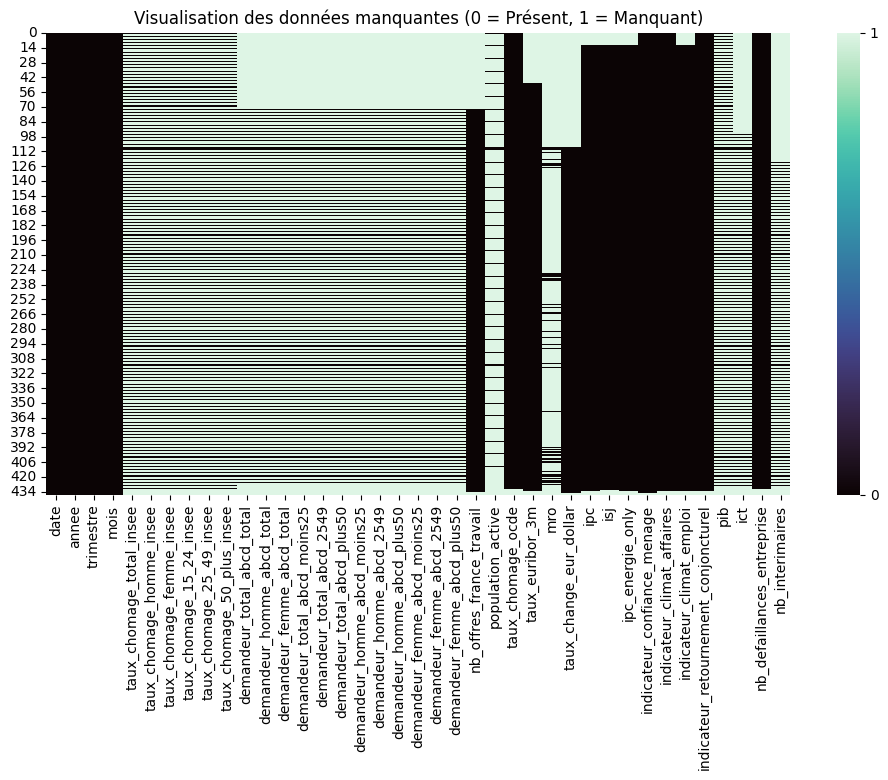

In [14]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), 
            vmin=0, 
            vmax=1, 
            cmap='mako', 
            cbar_kws={'ticks': [0, 1]})

plt.title("Visualisation des données manquantes (0 = Présent, 1 = Manquant)")
plt.show()

### Traitement de la colonne "mro"

On propage le taux directeur (ponctuel) sur les mois suivants pour qu'il soit "actif" dans le calcul de la moyenne trimestrielle

In [15]:
df['mro'] = df['mro'].ffill()

### Définition des règles d'agrégation vers le trimestriel

In [16]:
cols_trim_prev = [
    'taux_chomage_total_insee', 'taux_chomage_homme_insee', 'taux_chomage_femme_insee',
    'taux_chomage_15_24_insee', 'taux_chomage_25_49_insee', 'taux_chomage_50_plus_insee',
    'demandeur_total_abcd_total', 'demandeur_homme_abcd_total', 'demandeur_femme_abcd_total',
    'demandeur_total_abcd_moins25', 'demandeur_total_abcd_2549', 'demandeur_total_abcd_plus50',
    'demandeur_homme_abcd_moins25', 'demandeur_homme_abcd_2549', 'demandeur_homme_abcd_plus50',
    'demandeur_femme_abcd_moins25', 'demandeur_femme_abcd_2549', 'demandeur_femme_abcd_plus50',
    'population_active', 'pib', 'ict', 'nb_interimaires'
]

In [17]:
# Agrégation selon la nature de la donnée
agg_dict = {}
for col in cols_trim_prev:
    if col in df.columns: agg_dict[col] = 'first'

In [18]:
# Variables mensuelles (Moyenne)
for col in ['taux_euribor_3m', 'mro', 'taux_change_eur_dollar', 'ipc', 'isj', 'ipc_energie_only', 'taux_chomage_ocde']:
    if col in df.columns: agg_dict[col] = 'mean'

In [19]:
# Variables de flux (Somme)
for col in ['nb_defaillances_entreprise', 'nb_offres_france_travail']:
    if col in df.columns: agg_dict[col] = 'sum'

In [20]:
# Variables de sentiment (Dernière valeur du trimestre)
for col in ['indicateur_confiance_menage', 'indicateur_climat_affaires', 'indicateur_climat_emploi', 'indicateur_retournement_conjoncturel']:
    if col in df.columns: agg_dict[col] = 'last'

## Passage au format Trimestriel (Resampling)

In [21]:
# 'QS' = Quarter Start (L'index sera le 01/01, 01/04, 01/07, 01/10)
df_q = df.set_index('date').resample('QS').agg(agg_dict)

In [22]:
df_q.tail(10)

,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,...,ipc,isj,ipc_energie_only,taux_chomage_ocde,nb_defaillances_entreprise,nb_offres_france_travail,indicateur_confiance_menage,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel
date,,,,,,,,,,,,,,,,,,,,,
2023-10-01,7.5,7.6,7.4,17.6,7.0,5.0,5395100.0,2616000.0,2779100.0,690200.0,...,3.733333,3.700000,4.666667,7.566667,16525.0,874200.0,89.299483,98.9,101.0,-0.70
2024-01-01,7.5,7.7,7.3,18.1,6.8,5.1,5392100.0,2619700.0,2772400.0,689100.0,...,2.800000,2.600000,3.200000,7.466667,17684.0,986000.0,91.081040,100.4,100.9,-0.08
2024-04-01,7.3,7.3,7.4,18.0,6.6,5.0,5389800.0,2623000.0,2766800.0,688700.0,...,2.233333,1.800000,4.766667,7.366667,16434.0,943500.0,89.793544,99.6,100.1,-0.03
2024-07-01,7.4,7.6,7.1,19.7,6.6,4.7,5412400.0,2637700.0,2774700.0,692700.0,...,1.733333,1.533333,1.866667,7.400000,13756.0,944500.0,95.207348,97.4,98.6,-0.80
2024-10-01,7.3,7.4,7.1,18.7,6.6,4.7,5491700.0,2678900.0,2812800.0,716800.0,...,1.266667,1.400000,-0.500000,7.300000,18405.0,789700.0,88.566046,95.0,96.5,-0.90
2025-01-01,7.5,7.5,7.4,19.2,6.8,4.8,5738000.0,2811000.0,2927000.0,866800.0,...,1.100000,1.333333,-3.233333,7.466667,18156.0,828800.0,90.964128,96.6,96.4,-0.60
2025-04-01,7.6,7.7,7.4,19.1,6.9,4.8,5612100.0,2749800.0,2862300.0,792800.0,...,0.833333,1.200000,-7.500000,7.566667,17295.0,804900.0,88.493880,96.0,98.3,-0.20
2025-07-01,7.7,7.7,7.7,19.1,7.1,5.1,NaN,NaN,NaN,NaN,...,1.033333,1.333333,-5.933333,7.700000,14479.0,754400.0,88.088729,95.9,93.4,-0.50
2025-10-01,7.9,8.1,7.6,21.5,6.9,5.1,NaN,NaN,NaN,NaN,...,0.866667,1.100000,-5.666667,7.700000,6364.0,675300.0,89.840363,98.7,94.5,0.10


### Population active : interpolation linéaire

In [23]:
# Population active : interpolation linéaire pour passer de l'année aux trimestres
df_q['population_active'] = df_q['population_active'].interpolate(method='linear')

## Vérification des valeurs manquantes

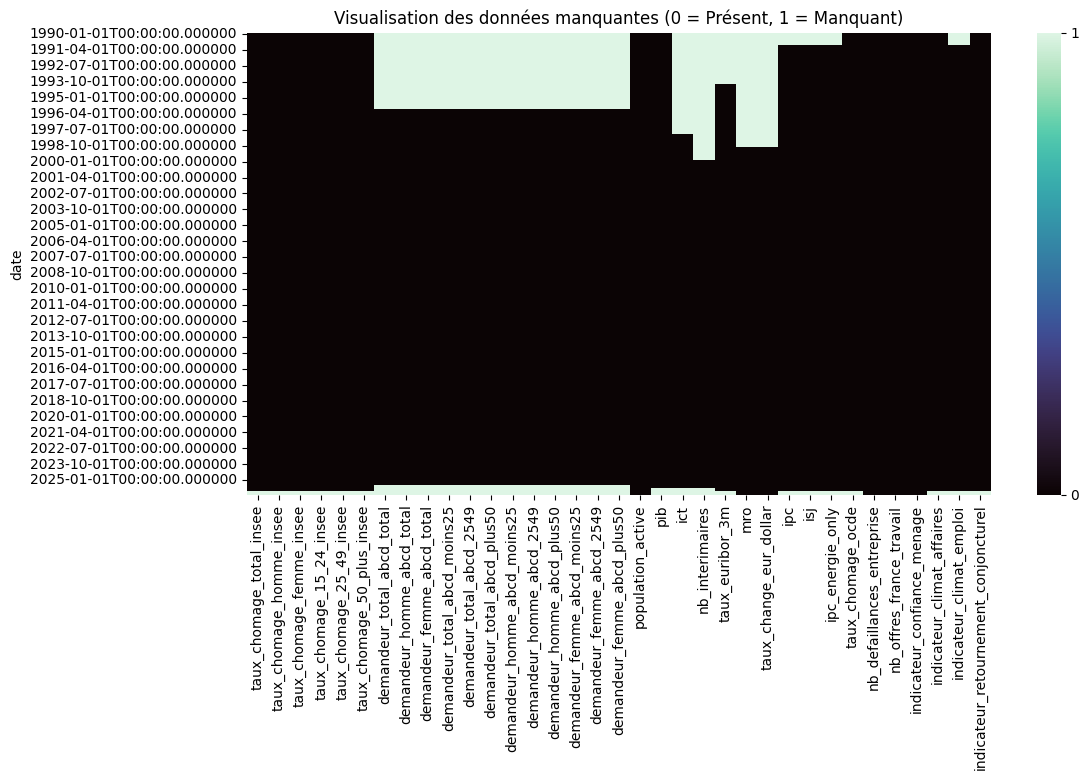

In [24]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_q.isna(), 
            vmin=0, 
            vmax=1, 
            cmap='mako', 
            cbar_kws={'ticks': [0, 1]})

plt.title("Visualisation des données manquantes (0 = Présent, 1 = Manquant)")
plt.show()

#### Commentaires

- `population_active` sera traité par interpolation linéaire.
- Toutes les colonnes impliquant les demandeurs d'emploi (colonnes commencant par "demandeur") ainsi que `ict`, `nb_interimaires` etc. qui commence bien après 1990 --> Nous raccourcirons la période du dataframe, début au 01/01/2000

# Feature Engineering

### Population active `population_active` : Taux de variation

on  applique le taux de variation *pct_change*
- L'argument mathématique : Élimination de tendance. Cette série est structurellement haussière.
- L'argument métier : Pression démographique. Si la population active augmente plus vite que l'emploi, le chômage monte mécaniquement.

In [25]:
df_q['population_active_var'] = df_q['population_active'].pct_change()

### Offres d'emplois collectées par France Travail `nb_offres_france_travail` : Taux de variation

Capte la "pression" démographique. On veut savoir si l'offre de bras augmente plus vite que les emplois.

In [26]:
df_q['nb_offres_france_travail_var'] = df_q['nb_offres_france_travail'].pct_change()

### Nombre de défaillance d'entreprise `nb_defaillances_entreprise` : Taux de variation

- L'argument mathématique : Vitesse de dégradation. On observe le taux de croissance des faillites.
- L'argument métier : Destruction d'emplois. Les faillites sont des licenciements économiques immédiats.

In [27]:
df_q['nb_defaillances_entreprise_var'] = df_q['nb_defaillances_entreprise'].pct_change()

### Nombre d'intérimaires `nb_interimaires` : Taux de variation

- L'argument mathématique : Stationnarisation. L'intérim est très volatil, le pct_change capture les cycles courts.
- L'argument métier : Le "Canari dans la mine". C'est la première variable qui baisse avant une crise et la première qui monte lors d'une reprise.

In [28]:
df_q['nb_interimaires_var'] = df_q['nb_interimaires'].pct_change()

### PIB `pib` : Taux de variation (%change ET log_diff)

- L'argument mathématique (Stationnarité) : Le PIB en valeur brute (ex: 600 milliards €) est une série "non-stationnaire". Elle augmente presque toujours avec le temps. Si on l'utilise brute, un modèle risque de créer une corrélation artificielle simplement parce que les deux courbes montent. En calculant le taux de variation, on rend la donnée stationnaire, ce qui est indispensable pour la plupart des algorithmes.

- L'argument métier (Loi d'Okun) : Ce n'est pas la richesse totale d'un pays qui crée de l'emploi, c'est sa croissance. En économie, on observe qu'il faut un certain niveau de croissance trimestrielle pour stabiliser ou réduire le chômage.

In [29]:
# Croissance du PIB (Trimestre sur Trimestre)
#df_q['pib_qoq'] = df_q['pib'].pct_change()

In [30]:
# Croissance du PIB en Log-différence. La transformation Δln(PIB) est la norme pour obtenir un taux de croissance stationnaire.
df_q['pib_logdiff'] = np.log(df_q['pib']).diff()

#### Ajout d'un lag au PIB

In [31]:
# On décale la croissance du PIB d'un trimestre (T-1)
df_q['pib_logdiff_lag'] = df_q['pib_logdiff'].shift(1)

## Inflation `ipc` et `ipc_energie_only` : passage en glissement annuel (diff)
- L'argument mathématique (Saisonnalité) : Les prix varient selon les mois (soldes, énergie en hiver). En comparant l'indice T par rapport à T−4 (même trimestre de l'année précédente), on élimine naturellement ces effets saisonniers sans avoir besoin de calculs complexes.

- L'argument métier : C'est la mesure standard de l'inflation. Elle reflète le pouvoir d'achat réel. Une inflation trop forte peut freiner la consommation et donc augmenter le chômage à terme.

In [32]:
# Inflation réelle (Glissement annuel - comparaison avec T-4)
#df_q['ipc_yoy'] = df_q['ipc'].pct_change(periods=4)
df_q['ipc_yoy'] = df_q['ipc'].diff(periods=4)

# Inflation de l'énergie (Glissement annuel - comparaison avec T-4)
#df_q['ipc_energie_only_yoy'] = df_q['ipc_energie_only'].pct_change(periods=4)
df_q['ipc_energie_only_yoy'] = df_q['ipc_energie_only'].diff(periods=4)


#Remarque : passage à la fonction .diff() pour obtenir la variation en "Points" (Absolue).

# pct_change() donne la variation en pourcentage, cependant en faisant ainsi on calculait "l'inflation de l'inflation" et on obtenait des valeurs abérrantes (notamment un "infini" à un endroit)

### Évolution du coût du travail (ICT) : Taux de variation (% change)

- L'argument mathématique : Accélération relative. On mesure la vitesse de croissance du coût salarial.
- L'argument métier : Pouvoir d'achat vs Marges. Une hausse trop forte sans productivité dégrade l'emploi.

In [33]:
# ICT - Indice du Coût du Travail
df_q['ict_var'] = df_q['ict'].pct_change()

### Évolution du coût du des salaires (ISJ) : Taux de variation en points (diff)

In [34]:
# ISJ - Indice de Salaire Journalier
df_q['isj_diff'] = df_q['isj'].diff()

## Taux de Chômage : passage en différence première

- L'argument mathématique (Autocorrélation) : Le taux de chômage est très "inerte". S'il est de 7,5% ce trimestre, il y a 99% de chances qu'il soit proche de 7,5% le mois prochain. Prédire la valeur brute est trop facile et n'apporte rien. Un taux est une proportion ; on étudie sa variation en points yt​−yt−1​.

- L'argument métier : C'est l'indicateur central de santé sociale du pays. Ce qui intéresse le décideur, c'est de savoir si le chômage accélère, stagne ou recule. En prédisant la variation (Δ), on se concentre sur les points d'inflexion de l'économie.

In [35]:
# Variation du chômage INSEE (Cible : combien de points on gagne ou perd ce trimestre)
df_q['taux_chomage_total_insee_diff'] = df_q['taux_chomage_total_insee'].diff()

In [36]:
# Variation du chômage OCDE
df_q['taux_chomage_ocde_diff'] = df_q['taux_chomage_ocde'].diff()

## Indices de Climat et de Confiance : standardisation

- L'argument mathématique (Mise à l'échelle) : Les indices de climat sont souvent basés sur 100, tandis que les taux d'intérêt sont entre 0 et 4. Si on les met ensemble dans un modèle sans transformation, le modèle donnera plus de poids aux variables ayant les plus gros chiffres (l'indice 100).

- L'argument métier : Le Z-score permet de répondre à la question : "La confiance des patrons est-elle exceptionnellement basse par rapport à l'histoire ?". Un score de -2 signifie que nous sommes dans une crise majeure (comme 2008 ou Covid), peu importe l'unité de mesure originale.

In [37]:
# Standardisation (Z-Score) du climat des affaires
# Permet de voir si on est historiquement au dessus ou en dessous de la normale
for col in ['indicateur_confiance_menage', 'indicateur_climat_affaires', 'indicateur_climat_emploi']:
    df_q[f'{col}_zscore'] = (df_q[col] - df_q[col].mean()) / df_q[col].std()

## Indicateur de Confiance des Ménages `indicateur_confiance_menage` : Taux de variation en points (diff)

Capte le basculement moral (optimisme vs pessimisme).

In [38]:
df_q['indicateur_confiance_menage_diff'] = df_q['indicateur_confiance_menage'].diff()

## Indicateur du Climat des Emplois `indicateur_climat_emploi` : Taux de variation en points (diff)

In [39]:
df_q['indicateur_climat_emploi_diff'] = df_q['indicateur_climat_emploi'].diff()

## Climat des affaires `indicateur_climat_affaires` : Taux de variation en points (diff)
- L'argument mathématique (Causalité temporelle) : Dans une série temporelle, la cause (X) précède souvent l'effet (Y). Si on utilise les variables du même trimestre, on fait de la corrélation. Si on utilise X au trimestre précédent pour prédire Y aujourd'hui, on fait de la prédiction.

- L'argument métier (Délai de décision) : Un chef d'entreprise qui perd confiance (baisse du climat des affaires) ne licencie pas le jour même. Il y a un temps de latence administratif et social. Intégrer un lag permet au modèle de capter ce délai de réaction.

In [40]:
df_q['indicateur_climat_affaires_diff'] = df_q['indicateur_climat_affaires'].diff()

#### Climat des affaires : variable décalé (lag)

In [41]:
# Création de "Lags" (Variables décalées)
# Très important : le climat des affaires d'aujourd'hui prédit souvent le chômage de demain
df_q['indicateur_climat_affaires_diff_lag'] = df_q['indicateur_climat_affaires_diff'].shift(1)

## Taux Euribor 3M `taux_euribor_3m` : taux de variation (diff)

- L'argument mathématique : Capture de choc. Les taux sont persistants, seule leur variation brusque impacte les modèles.

- L'argument métier : Coût du crédit. Une hausse renchérit le financement court terme des entreprises.

In [42]:
df_q['taux_euribor_3m_diff'] = df_q['taux_euribor_3m'].diff()

### MRO `mro` : taux de variation (diff)

- L'argument mathématique : Différence discrète. C'est une fonction en escalier ; la différence isole les dates de pivot monétaire.
- L'argument métier : Signal de la BCE. Une hausse du MRO est un frein volontaire mis sur l'économie pour freiner l'inflation.

In [43]:
df_q['mro_diff'] = df_q['mro'].diff()

### Taux de change EURO<>DOLLAR `taux_change_eur_dollar` : taux de variation (% change)

Exception ici : pour une monnaie, on veut voir la dépréciation/appréciation relative.

In [44]:
df_q['taux_change_eur_dollar_var'] = df_q['taux_change_eur_dollar'].pct_change()

### Dummy" COVID (Le choc exogène)

On crée une colonne qui prévient l'IA que la période est spéciale

In [45]:
df_q['is_covid'] = ((df_q.index >= '2020-03-01') & (df_q.index <= '2021-06-01')).astype(int)

In [46]:
df_q.tail(20)

,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,...,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_confiance_menage_diff,indicateur_climat_emploi_diff,indicateur_climat_affaires_diff,indicateur_climat_affaires_diff_lag,taux_euribor_3m_diff,mro_diff,taux_change_eur_dollar_var,is_covid
date,,,,,,,,,,,,,,,,,,,,,
2021-04-01,7.9,8.0,7.9,19.4,7.1,5.9,5975700.0,2889800.0,3085900.0,767900.0,...,1.576201,0.682125,8.668164,15.8,17.0,5.0,0.002067,0.000000,0.005141,1
2021-07-01,7.9,7.8,8.0,18.6,7.1,5.8,5845800.0,2823700.0,3022100.0,733000.0,...,1.240628,0.671596,-2.096494,-0.1,-3.2,17.0,-0.005400,0.000000,-0.023862,0
2021-10-01,7.4,7.5,7.3,16.5,6.7,5.7,5678000.0,2734900.0,2943100.0,694600.0,...,1.104302,1.082225,-3.512301,3.9,-1.3,-3.2,-0.020600,0.000000,-0.027476,0
2022-01-01,7.4,7.4,7.4,16.8,6.7,5.5,5533100.0,2655900.0,2877200.0,670000.0,...,0.737269,1.429680,-10.436119,3.3,-3.5,-1.3,0.037400,0.000000,-0.025572,0
2022-04-01,7.4,7.6,7.2,18.1,6.7,5.1,5450300.0,2614900.0,2835400.0,660300.0,...,0.485590,0.955877,-6.689992,-4.5,-2.4,-3.5,0.171400,0.000000,-0.054280,0
2022-07-01,7.2,7.4,7.0,17.5,6.4,5.1,5432600.0,2608600.0,2824000.0,664500.0,...,0.202450,0.871646,-1.656779,-0.8,-2.7,-2.4,0.838333,0.750000,-0.053540,0
2022-10-01,7.1,7.3,6.9,16.9,6.4,5.0,5382600.0,2588100.0,2794500.0,661900.0,...,0.328290,1.050638,1.811774,1.7,1.2,-2.7,1.291400,1.166667,0.033727,0
2023-01-01,7.1,7.4,6.8,16.6,6.4,5.2,5363400.0,2582700.0,2780700.0,662100.0,...,0.286344,1.008522,-1.067788,-0.4,-0.4,1.2,0.859800,1.083333,0.044289,0
2023-04-01,7.2,7.4,7.1,17.1,6.6,5.1,5348000.0,2580200.0,2767800.0,667100.0,...,0.055637,0.682125,4.574129,-3.1,-2.2,-0.4,0.724500,0.750000,0.006280,0


# Filtrage des données

## Ajustement des périodes

Afin d'harmoniser les périodes de toutes les colonnes

In [47]:
# Filtrage de la période  : 1er Janvier 2000 au 2ème trimestre 2025
df_q = df_q.loc['2000-01-01':'2025-07-01']

### Nouveau résumé des valeurs manquantes

In [48]:
df_q.isna().sum()

taux_chomage_total_insee                0
taux_chomage_homme_insee                0
taux_chomage_femme_insee                0
taux_chomage_15_24_insee                0
taux_chomage_25_49_insee                0
taux_chomage_50_plus_insee              0
demandeur_total_abcd_total              1
demandeur_homme_abcd_total              1
demandeur_femme_abcd_total              1
demandeur_total_abcd_moins25            1
demandeur_total_abcd_2549               1
demandeur_total_abcd_plus50             1
demandeur_homme_abcd_moins25            1
demandeur_homme_abcd_2549               1
demandeur_homme_abcd_plus50             1
demandeur_femme_abcd_moins25            1
demandeur_femme_abcd_2549               1
demandeur_femme_abcd_plus50             1
population_active                       0
pib                                     0
ict                                     0
nb_interimaires                         0
taux_euribor_3m                         0
mro                               

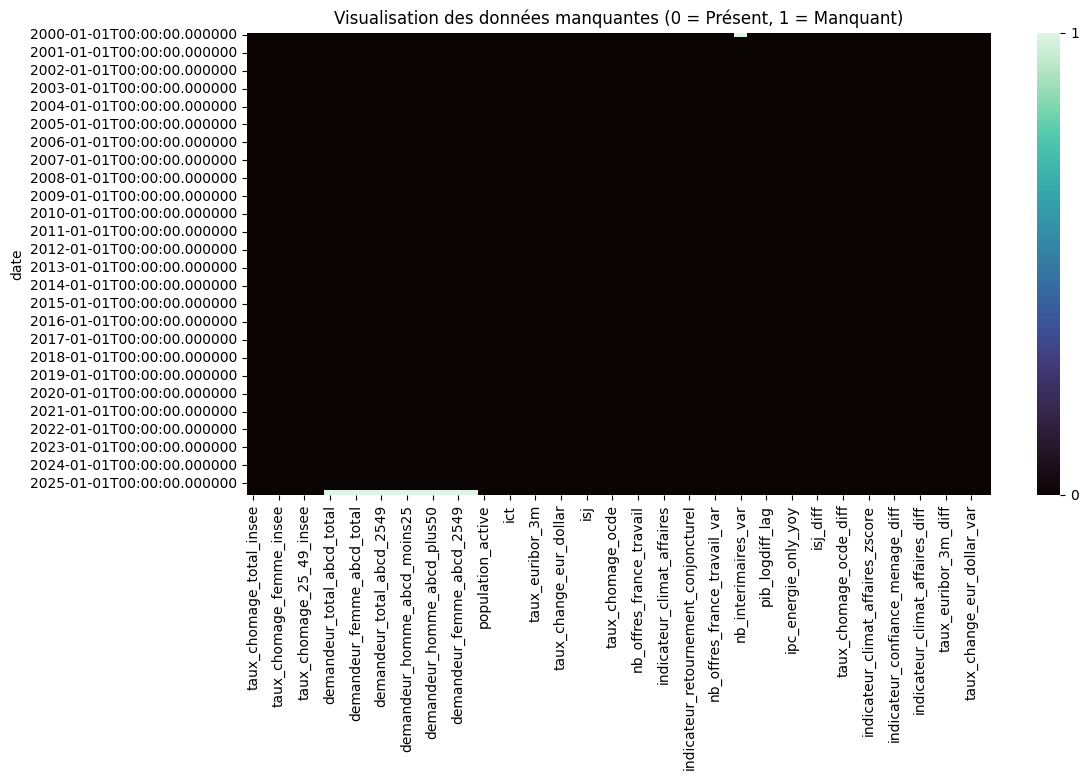

In [49]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_q.isna(), 
            vmin=0, 
            vmax=1, 
            cmap='mako', 
            cbar_kws={'ticks': [0, 1]})

plt.title("Visualisation des données manquantes (0 = Présent, 1 = Manquant)")
plt.show()

#### Ajustement des dernières valeurs manquantes

In [50]:
df_q = df_q.bfill()
df_q = df_q.ffill()

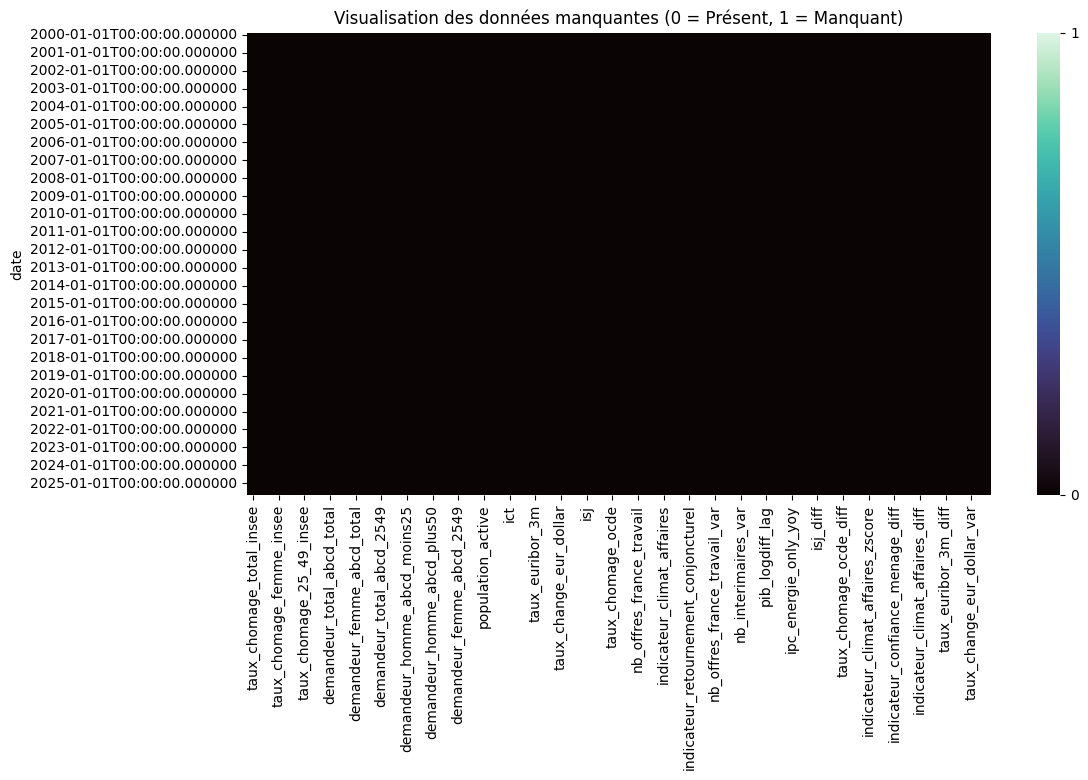

In [51]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_q.isna(), 
            vmin=0, 
            vmax=1, 
            cmap='mako', 
            cbar_kws={'ticks': [0, 1]})

plt.title("Visualisation des données manquantes (0 = Présent, 1 = Manquant)")
plt.show()

#### Dernière vérification des valeurs manquantes

In [52]:
print(df_q.isna().sum())

taux_chomage_total_insee                0
taux_chomage_homme_insee                0
taux_chomage_femme_insee                0
taux_chomage_15_24_insee                0
taux_chomage_25_49_insee                0
taux_chomage_50_plus_insee              0
demandeur_total_abcd_total              0
demandeur_homme_abcd_total              0
demandeur_femme_abcd_total              0
demandeur_total_abcd_moins25            0
demandeur_total_abcd_2549               0
demandeur_total_abcd_plus50             0
demandeur_homme_abcd_moins25            0
demandeur_homme_abcd_2549               0
demandeur_homme_abcd_plus50             0
demandeur_femme_abcd_moins25            0
demandeur_femme_abcd_2549               0
demandeur_femme_abcd_plus50             0
population_active                       0
pib                                     0
ict                                     0
nb_interimaires                         0
taux_euribor_3m                         0
mro                               

# Visualisation du dataframe final

In [53]:
df_q.head(10)

,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,...,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_confiance_menage_diff,indicateur_climat_emploi_diff,indicateur_climat_affaires_diff,indicateur_climat_affaires_diff_lag,taux_euribor_3m_diff,mro_diff,taux_change_eur_dollar_var,is_covid
date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,9.1,8.0,10.3,19.0,8.4,6.1,4018600.0,1774200.0,2244400.0,690800.0,...,1.723014,1.345448,0.389039,-4.1,-4.3,5.9,0.112500,0.416667,-0.050268,0
2000-04-01,8.7,7.6,9.9,18.0,8.0,5.8,3890000.0,1701100.0,2188900.0,654800.0,...,1.754474,1.977185,3.053740,6.0,0.3,-4.3,0.720700,0.666667,-0.038337,0
2000-07-01,8.4,7.2,9.6,17.4,7.8,5.5,3807900.0,1659300.0,2148600.0,632600.0,...,1.901287,1.861366,-4.481288,-1.1,1.4,0.3,0.474600,0.333333,-0.036859,0
2000-10-01,8.0,6.9,9.4,16.9,7.5,5.2,3690300.0,1601400.0,2088900.0,604600.0,...,1.492307,1.966656,4.852425,1.0,-3.9,1.4,0.286567,0.000000,-0.018875,0
2001-01-01,7.8,6.6,9.2,16.8,7.3,4.9,3609400.0,1565300.0,2044100.0,588000.0,...,1.376954,1.819251,-1.117994,-1.4,-1.1,-3.9,-0.279133,0.000000,0.036620,0
2001-04-01,7.7,6.5,9.1,16.7,7.2,4.9,3581100.0,1558900.0,2022200.0,586200.0,...,0.422670,1.061167,-7.837192,-7.2,-9.1,-1.1,-0.154267,0.000000,-0.056150,0
2001-07-01,7.7,6.7,8.9,17.0,7.2,4.9,3592500.0,1578300.0,2014200.0,597800.0,...,-0.154095,0.724241,-4.028212,-3.2,-5.5,-9.1,-0.322933,0.000000,0.046756,0
2001-10-01,7.8,6.9,8.8,17.3,7.2,4.8,3658600.0,1627700.0,2030900.0,620900.0,...,-0.489668,0.334670,1.543558,-3.7,-3.2,-5.5,-0.824333,0.000000,-0.010760,0
2002-01-01,7.8,7.1,8.7,17.5,7.2,4.9,3693700.0,1663200.0,2030500.0,630400.0,...,-0.017769,0.134620,-0.222131,-1.9,4.5,-3.2,-0.081267,0.000000,-0.027698,0


In [54]:
df_q.tail(10)

,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,...,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_confiance_menage_diff,indicateur_climat_emploi_diff,indicateur_climat_affaires_diff,indicateur_climat_affaires_diff_lag,taux_euribor_3m_diff,mro_diff,taux_change_eur_dollar_var,is_covid
date,,,,,,,,,,,,,,,,,,,,,
2023-04-01,7.2,7.4,7.1,17.1,6.6,5.1,5348000.0,2580200.0,2767800.0,667100.0,...,0.055637,0.682125,4.574129,-3.1,-2.2,-0.4,0.724500,0.750000,0.006280,0
2023-07-01,7.4,7.3,7.4,17.4,6.7,5.1,5364800.0,2592700.0,2772100.0,678000.0,...,-0.038742,0.418901,-1.448094,-2.5,-0.9,-2.2,0.420933,0.500000,-0.001383,0
2023-10-01,7.5,7.6,7.4,17.6,7.0,5.0,5395100.0,2616000.0,2779100.0,690200.0,...,-0.143609,0.092504,4.795492,-3.1,-1.0,-0.9,0.180067,0.250000,0.003540,0
2024-01-01,7.5,7.7,7.3,18.1,6.8,5.1,5392100.0,2619700.0,2772400.0,689100.0,...,0.013691,0.081975,1.781557,-0.1,1.5,-1.0,-0.033800,0.000000,-0.003865,0
2024-04-01,7.3,7.3,7.4,18.0,6.6,5.0,5389800.0,2623000.0,2766800.0,688700.0,...,-0.070202,-0.002256,-1.287497,-0.8,-0.8,1.5,-0.115433,-0.083333,-0.006128,0
2024-07-01,7.4,7.6,7.1,19.7,6.6,4.7,5412400.0,2637700.0,2774700.0,692700.0,...,-0.300908,-0.160190,5.413804,-1.5,-2.2,-0.8,-0.252833,-0.366667,0.025902,0
2024-10-01,7.3,7.4,7.1,18.7,6.6,4.7,5491700.0,2678900.0,2812800.0,716800.0,...,-0.552588,-0.381298,-6.641302,-2.1,-2.4,-2.2,-0.558867,-0.733333,-0.038597,0
2025-01-01,7.5,7.5,7.4,19.2,6.8,4.8,5738000.0,2811000.0,2927000.0,866800.0,...,-0.384802,-0.391827,2.398082,-0.1,1.6,-2.4,-0.439667,-0.416667,-0.006723,0
2025-04-01,7.6,7.7,7.4,19.1,6.9,4.8,5612100.0,2749800.0,2862300.0,792800.0,...,-0.447721,-0.191777,-2.470248,1.9,-0.6,1.6,-0.449133,-0.583333,0.088965,0


# Export du dataset au format CSV (SILVER)

In [55]:
repertoire_data_processed = Path.cwd().parent.parent / "data" / "processed"
chemin_export = repertoire_data_processed / "02_dataset_silver.csv"

df_q.to_csv(chemin_export, index=True, encoding='utf-8')